In [1]:
!pip install pandas_datareader

Looking in indexes: http://nexus.charisma:5080/repository/pypi-proxy/simple


In [1]:
import os
import json
import numpy as np
import pandas as pd
import yfinance as yf
import requests
from pandas_datareader import data as pdr

START = "1995-01-01"
END   = "2025-12-01"
MARKET = "SPY"  # or "^GSPC"

FRED_SERIES = {
    "DFF": "fed_funds",
    "DGS10": "rate_10y",
    "DGS2": "rate_2y",
    "T10Y2Y": "yc_slope_10y2y",
    "CPIAUCSL": "cpi",
    "UNRATE": "unemp",
    "INDPRO": "indpro",
}

# Evaluation eras (held out from training)
SPLITS = {
    "gfc_2008_2010": ("2008-01-01", "2010-12-31"),
    "covid_2020_2021": ("2020-01-01", "2021-12-31"),
    "inflation_2022_2023": ("2022-01-01", "2023-12-31"),
}

OUT_ROOT = "dataset_finance"


def ensure_dirs():
    os.makedirs(os.path.join(OUT_ROOT, "metadata"), exist_ok=True)
    os.makedirs(os.path.join(OUT_ROOT, "finetune"), exist_ok=True)
    os.makedirs(os.path.join(OUT_ROOT, "eval"), exist_ok=True)


def get_sp500_tickers() -> list[str]:
    url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/91.0.4472.124 Safari/537.36"
        )
    }
    response = requests.get(url, headers=headers, timeout=30)
    response.raise_for_status()
    tickers = pd.read_html(response.text)[0]["Symbol"].astype(str).tolist()
    return [t.replace(".", "-") for t in tickers]


def download_close(tickers: list[str], start: str, end: str) -> pd.DataFrame:
    px = yf.download(
        tickers=tickers,
        start=start,
        end=end,
        auto_adjust=False,
        progress=False,
        group_by="ticker",
        threads=True,
    )

    price_field = "Close"  # or "Adj Close"

    if isinstance(px.columns, pd.MultiIndex):
        close = pd.concat(
            {t: px[t][price_field] for t in tickers if t in px.columns.get_level_values(0)},
            axis=1,
        )
    else:
        close = px[price_field].to_frame(tickers[0])

    return close.sort_index()


def log_returns(close_df: pd.DataFrame) -> pd.DataFrame:
    return np.log(close_df).diff()


def download_fred(series_map: dict, start: str, end: str) -> pd.DataFrame:
    macro = pdr.DataReader(list(series_map.keys()), "fred", start, end)
    return macro.rename(columns=series_map).sort_index()


def save_metadata(tickers: list[str]):
    pd.Series(tickers, name="ticker").to_csv(os.path.join(OUT_ROOT, "metadata", "tickers.csv"), index=False)
    pd.DataFrame({"fred_code": list(FRED_SERIES.keys()), "name": list(FRED_SERIES.values())}).to_csv(
        os.path.join(OUT_ROOT, "metadata", "fred_series.csv"), index=False
    )
    with open(os.path.join(OUT_ROOT, "metadata", "build_config.json"), "w") as f:
        json.dump(
            {"start": START, "end": END, "market": MARKET, "fred_series": FRED_SERIES, "splits": SPLITS},
            f,
            indent=2,
        )


def _build_exclusion_mask(index: pd.DatetimeIndex, splits: dict) -> pd.Series:
    """True = keep for training, False = exclude (eval eras)."""
    keep = pd.Series(True, index=index)
    for _, (a, b) in splits.items():
        keep.loc[a:b] = False
    return keep


def _contiguous_segments_from_masked_series(
    s: pd.Series,
    keep_mask: pd.Series,
    min_len: int,
    max_gap_days: int = 7,
):
    """
    Returns list of contiguous sequences from s where keep_mask is True.
    Contiguity is defined by date gaps <= max_gap_days (trading calendar gaps OK).
    """
    # Keep only dates allowed for training
    s2 = s[keep_mask].dropna()
    if len(s2) == 0:
        return []

    # Identify breaks where the date gap is too large
    dt = s2.index.to_series().diff().dt.days.fillna(1)
    # A large gap implies we're jumping across excluded eras or missing chunks
    breaks = (dt > max_gap_days).cumsum()

    segments = []
    for _, seg in s2.groupby(breaks):
        if len(seg) >= min_len:
            segments.append(seg.astype(float).to_list())
    return segments


def write_train_jsonl_contiguous(
    returns_df: pd.DataFrame,
    splits: dict,
    out_path: str,
    min_len: int = 512,
    max_gap_days: int = 7,
):
    """
    Writes ONE jsonl file with MANY sequences (recommended for your training pipeline).
    Each line:
      {"ticker":"AAPL","segment_id":0,"sequence":[...]}
    """
    os.makedirs(os.path.dirname(out_path) or ".", exist_ok=True)

    keep_mask = _build_exclusion_mask(returns_df.index, splits)

    n_seq = 0
    n_tickers = 0

    with open(out_path, "w", encoding="utf-8") as f:
        for t in returns_df.columns:
            s = returns_df[t]
            segs = _contiguous_segments_from_masked_series(
                s, keep_mask=keep_mask, min_len=min_len, max_gap_days=max_gap_days
            )
            if not segs:
                continue

            n_tickers += 1
            for j, seq in enumerate(segs):
                obj = {"ticker": t, "segment_id": j, "sequence": seq}
                f.write(json.dumps(obj) + "\n")
                n_seq += 1

    total_dates = len(returns_df.index)
    train_dates = int(keep_mask.sum())
    eval_dates = total_dates - train_dates

    print(f"[split] total dates={total_dates} | train dates={train_dates} | eval-excluded dates={eval_dates}")
    print(f"[train.jsonl] wrote {n_seq} sequences from {n_tickers} tickers to {out_path}")


def write_eval_csvs(panel_wide: pd.DataFrame, splits: dict):
    eval_dir = os.path.join(OUT_ROOT, "eval")
    os.makedirs(eval_dir, exist_ok=True)

    for name, (a, b) in splits.items():
        df = panel_wide.loc[a:b].copy()
        df.reset_index().rename(columns={"index": "date"}).to_csv(os.path.join(eval_dir, f"{name}.csv"), index=False)


def main():
    ensure_dirs()

    tickers = get_sp500_tickers()
    all_tickers = sorted(set(tickers + [MARKET]))
    save_metadata(tickers)

    # 1) prices -> returns
    close = download_close(all_tickers, START, END)
    rets = log_returns(close)

    market_ret = rets[MARKET].rename("market_ret_1d")

    # 2) macro aligned, ffill, shift(1)
    macro = download_fred(FRED_SERIES, START, END)
    idx = rets.index
    macro = macro.reindex(idx).ffill().shift(1)

    # 3) panel for eval csvs
    firm_rets = rets.drop(columns=[MARKET], errors="ignore")
    panel_wide = firm_rets.copy()
    panel_wide["market_ret_1d"] = market_ret
    for c in macro.columns:
        panel_wide[c] = macro[c]
    panel_wide = panel_wide.dropna(subset=["market_ret_1d"])

    # 4) Write training jsonl: contiguous segments, no fake jumps
    out_train = os.path.join(OUT_ROOT, "finetune", "train.jsonl")
    write_train_jsonl_contiguous(
        returns_df=firm_rets,
        splits=SPLITS,
        out_path=out_train,
        min_len=512,         # choose based on your max_length/stride later
        max_gap_days=7,      # treat >7 days as a break
    )

    # Optional: write eval csvs for your run_eval script
    write_eval_csvs(panel_wide, SPLITS)

    print("Done.")
    print(f"Train JSONL: {out_train}")
    print(f"Eval CSVs:   {os.path.join(OUT_ROOT, 'eval')}")


if __name__ == "__main__":
    main()


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f692a34c640>>
Traceback (most recent call last):
  File "/home/aaburkova_1/.conda/envs/mama/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


ModuleNotFoundError: No module named 'yfinance'

In [27]:
import os
import json
from pathlib import Path

# Paths
JSONL_DIR = "dataset_finance/finetune/jsonl"
OUTPUT_FILE = "dataset_finance/finetune/train_sequences.jsonl"
OUTPUT_FILE_SMALL = "dataset_finance/finetune/train_sequences_small.jsonl"


def combine_jsonl_files():
    """
    Combine all JSONL files from jsonl folder into one file.
    Also creates a smaller version with first 10 sequences.
    """
    # Get all JSONL files
    jsonl_path = Path(JSONL_DIR)
    jsonl_files = sorted(jsonl_path.glob("*.jsonl"))
    
    if not jsonl_files:
        print(f"No JSONL files found in {JSONL_DIR}")
        return
    
    print(f"Found {len(jsonl_files)} JSONL files")
    
    # Read all sequences
    all_sequences = []
    total_observations = 0
    
    for jsonl_file in jsonl_files:
        try:
            with open(jsonl_file, 'r') as f:
                data = json.load(f)
                sequence = data.get("sequence", [])
                if sequence:  # Only add non-empty sequences
                    all_sequences.append({"sequence": sequence})
                    total_observations += len(sequence)
        except Exception as e:
            print(f"Warning: Could not read {jsonl_file}: {e}")
            continue
    
    # Write full file
    with open(OUTPUT_FILE, 'w') as f:
        for seq_data in all_sequences:
            f.write(json.dumps(seq_data) + '\n')
    
    # Write small file (first 10 sequences)
    with open(OUTPUT_FILE_SMALL, 'w') as f:
        for seq_data in all_sequences[:10]:
            f.write(json.dumps(seq_data) + '\n')
    
    # Calculate observations for small file
    small_observations = sum(len(seq["sequence"]) for seq in all_sequences[:10])
    
    # Print summary
    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)
    print(f"Full file ({OUTPUT_FILE}):")
    print(f"  - Sequences: {len(all_sequences):,}")
    print(f"  - Total observations: {total_observations:,}")
    print(f"\nSmall file ({OUTPUT_FILE_SMALL}):")
    print(f"  - Sequences: {min(10, len(all_sequences)):,}")
    print(f"  - Total observations: {small_observations:,}")
    print("="*60)


# Run the function
combine_jsonl_files()


Found 477 JSONL files

SUMMARY
Full file (dataset_finance/finetune/train_sequences.jsonl):
  - Sequences: 477
  - Total observations: 2,470,559

Small file (dataset_finance/finetune/train_sequences_small.jsonl):
  - Sequences: 10
  - Total observations: 53,323


In [19]:
import pandas as pd

file_name = "dataset_finance/eval/covid_2020_2021.csv"

df = pd.read_csv(file_name)
df
# df.dropna(axis=1).to_csv(file_name, index=False)

,date,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,...,ZBRA,ZTS,market_ret_1d,fed_funds,rate_10y,rate_2y,yc_slope_10y2y,cpi,unemp,indpro
0,2020-01-02,0.007474,0.022560,0.011343,0.001036,0.011821,-0.001997,0.013911,0.013291,-0.005191,...,0.014381,0.013434,0.009308,1.55,1.92,1.58,0.34,257.879,3.6,101.9372
1,2020-01-03,-0.016186,-0.009770,-0.009537,-0.012266,-0.001153,-0.001667,-0.007865,-0.017760,-0.001954,...,-0.011996,0.000149,-0.007601,1.55,1.88,1.58,0.30,257.879,3.6,101.9372
2,2020-01-06,0.002952,0.007937,0.007861,0.005226,0.003914,-0.006551,0.005710,-0.011818,-0.007853,...,0.007626,-0.007707,0.003808,1.55,1.80,1.53,0.27,257.879,3.6,101.9372
3,2020-01-07,0.003061,-0.004714,-0.005721,-0.005575,-0.008306,-0.021826,-0.000959,0.022496,-0.012119,...,-0.005987,0.003374,-0.002816,1.55,1.81,1.54,0.27,257.879,3.6,101.9372
4,2020-01-08,0.009825,0.015958,0.007062,0.004068,-0.010013,0.001960,0.013348,0.008991,-0.011146,...,-0.035036,-0.002173,0.005315,1.55,1.83,1.54,0.29,257.879,3.6,101.9372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
500,2021-12-27,0.005939,0.022715,0.009869,0.016393,0.010296,0.029368,0.014051,0.016144,0.009581,...,0.040250,0.016360,0.014053,0.08,1.50,0.71,0.79,280.806,3.9,100.5726
501,2021-12-28,0.002768,-0.005784,-0.000149,-0.007023,0.007710,-0.000144,-0.014507,-0.006231,0.012933,...,-0.014971,-0.009210,-0.000818,0.08,1.48,0.76,0.72,280.806,3.9,100.5726
502,2021-12-29,0.009192,0.000502,0.007192,0.005113,0.007427,0.000361,-0.000123,0.006516,0.001195,...,0.006342,0.011317,0.001278,0.08,1.49,0.74,0.75,280.806,3.9,100.5726
503,2021-12-30,0.001431,-0.006600,0.004202,-0.001347,-0.006072,-0.003835,0.002176,-0.004225,-0.002241,...,-0.005973,-0.007599,-0.002768,0.08,1.55,0.75,0.80,280.806,3.9,100.5726


In [10]:
import numpy as np

npz_path = 'results/eval_preds_attn_small_inflation.npz'
npz = np.load(npz_path)
preds2 = npz['predictions']
labels2 = npz['labels']

mse = np.sqrt(float(np.mean((preds2 - labels2) ** 2)))
mae = float(np.mean(np.abs(preds2 - labels2)))

print('RMSE =', mse)
print('MAE =', mae)

RMSE = 0.8876257471538881
MAE = 0.6423712968826294


In [3]:
import numpy as np

npz_path = 'results/eval_preds_attn_small2.npz'
npz = np.load(npz_path)
preds = npz['predictions']
labels = npz['labels']

mse = float(np.mean((preds - labels) ** 2))
mae = float(np.mean(np.abs(preds - labels)))

print('MSE =', mse)
print('MAE =', mae)

MSE = 2.0824360847473145
MAE = 0.932872474193573


In [5]:
print(preds[:, 0].shape)

(98784,)


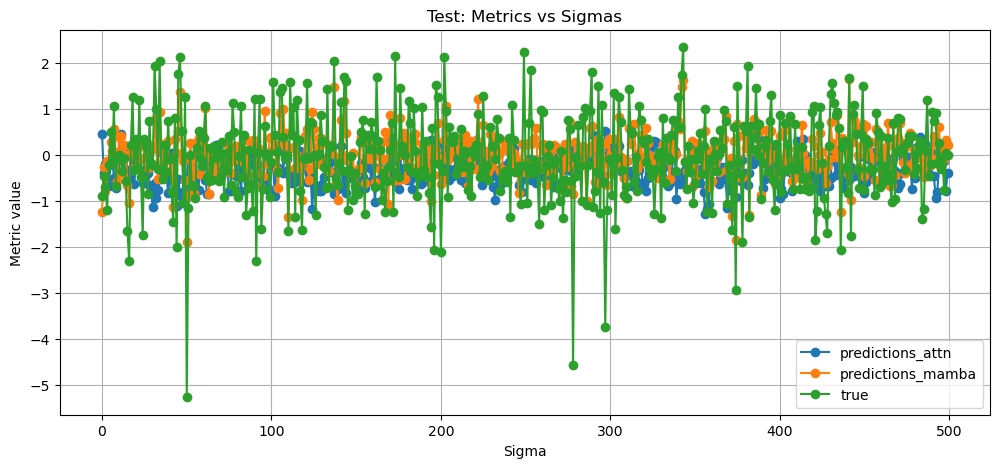

In [7]:
import matplotlib.pyplot as plt

xs = np.arange(preds[:, 0][:500].shape[0])


plt.figure(figsize=(12, 5))
plt.plot(xs, preds[:, 0][:500], marker="o", label="predictions_attn")
plt.plot(xs, preds2[:, 0][:500], marker="o", label="predictions_mamba")
plt.plot(xs, labels[:, 0][:500], marker="o", label="true")
plt.xlabel("Sigma")
plt.ylabel("Metric value")
plt.title("Test: Metrics vs Sigmas")
plt.grid(True)
plt.legend()
plt.show()

# plt.figure(figsize=(12, 5))
# plt.plot(xs, preds2[:, 0][:500], marker="o", label="predictions")
# plt.plot(xs, labels2[:, 0][:500], marker="o", label="true")
# plt.xlabel("Sigma")
# plt.ylabel("Metric value")
# plt.title("Test: Metrics vs Sigmas")
# plt.grid(True)
# plt.legend()
# plt.show()


ATTN preds shape: (17649, 64)
MAMBA preds shape: (17649, 64)
labels shape: (17649, 64)
n_series: 477
n_windows: 37
pred_len: 64
Eval slice start index: 149
First forecast date: 2021-08-11 00:00:00
Last forecast date: 2021-10-01 00:00:00
Expected true AAPL segment shape: (37,)
series_major: mean abs alignment error = 0.3734674974
window_major: mean abs alignment error = 0.3724624407

Chosen layout: window_major (alignment MAE=0.3724624407)
AAPL attn shape: (37, 64)
AAPL true shape: (37, 64)
AAPL mamba shape: (37, 64)
True-vs-CSV MAE: 0.37246244070069984


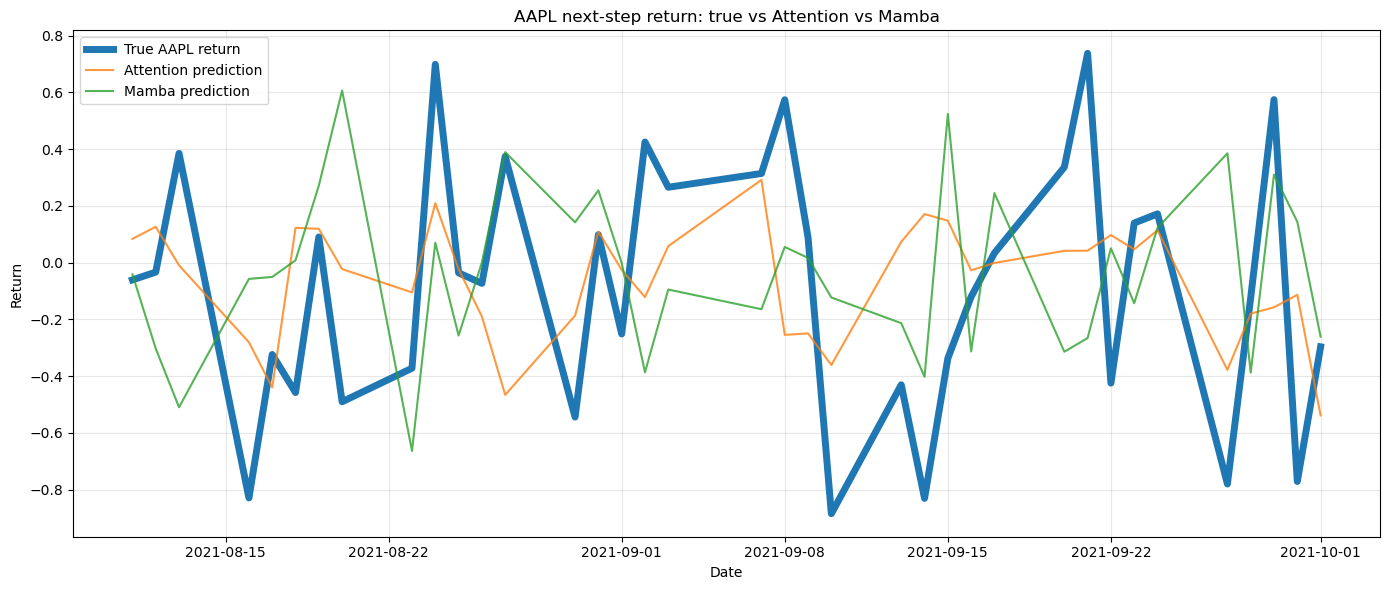

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

csv_path = "dataset_finance/eval/covid_2020_2021.csv"
attn_path = "results/eval_preds_attn_small_covid.npz"
mamba_path = "results/eval_preds_mamba_small_covid.npz"

prediction_length = 64
context_length = 256   # because run_eval uses p*4 for p=64 unless overridden
target = "AAPL"

# ---------- load csv ----------
df = pd.read_csv(csv_path)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

feature_cols = [c for c in df.columns if c != "date"]
n_series = len(feature_cols)
target_idx = feature_cols.index(target)

# ---------- load npz ----------
attn = np.load(attn_path)
mamba = np.load(mamba_path)

attn_preds = attn["predictions"]
attn_labels = attn["labels"]
mamba_preds = mamba["predictions"]

print("ATTN preds shape:", attn_preds.shape)
print("MAMBA preds shape:", mamba_preds.shape)
print("labels shape:", attn_labels.shape)
print("n_series:", n_series)

assert attn_preds.shape == attn_labels.shape == mamba_preds.shape
assert attn_preds.shape[0] % n_series == 0

n_windows = attn_preds.shape[0] // n_series
pred_len = attn_preds.shape[1]

print("n_windows:", n_windows)
print("pred_len:", pred_len)

# ---------- compute exact evaluation date block ----------
used_rows = context_length + n_windows + prediction_length - 1
eval_slice_start = len(df) - used_rows
first_label_idx = eval_slice_start + context_length
last_label_idx = first_label_idx + n_windows

dates_eval = df["date"].iloc[first_label_idx:last_label_idx].reset_index(drop=True)
true_aapl_from_csv = df[target].iloc[first_label_idx:last_label_idx].to_numpy()

print("Eval slice start index:", eval_slice_start)
print("First forecast date:", dates_eval.iloc[0])
print("Last forecast date:", dates_eval.iloc[-1])
print("Expected true AAPL segment shape:", true_aapl_from_csv.shape)

# ---------- try both possible reshapes ----------
def reshape_series_major(x):
    # assumes rows grouped by series first, then windows
    return x.reshape(n_series, n_windows, pred_len)

def reshape_window_major(x):
    # assumes rows grouped by windows first, then series
    return x.reshape(n_windows, n_series, pred_len).transpose(1, 0, 2)

candidates = {
    "series_major": (
        reshape_series_major(attn_preds),
        reshape_series_major(attn_labels),
        reshape_series_major(mamba_preds),
    ),
    "window_major": (
        reshape_window_major(attn_preds),
        reshape_window_major(attn_labels),
        reshape_window_major(mamba_preds),
    ),
}

best_name = None
best_err = None
best_pack = None

for name, (attn_3d, labels_3d, mamba_3d) in candidates.items():
    # compare t+1 labels for AAPL with actual AAPL values on eval dates
    candidate_true = labels_3d[target_idx, :, 0]
    err = np.mean(np.abs(candidate_true - true_aapl_from_csv))
    print(f"{name}: mean abs alignment error = {err:.10f}")

    if best_err is None or err < best_err:
        best_err = err
        best_name = name
        best_pack = (attn_3d, labels_3d, mamba_3d)

print(f"\nChosen layout: {best_name} (alignment MAE={best_err:.10f})")

attn_3d, labels_3d, mamba_3d = best_pack

# ---------- extract AAPL ----------
aapl_attn = attn_3d[target_idx]    # [n_windows, pred_len]
aapl_true = labels_3d[target_idx]  # [n_windows, pred_len]
aapl_mamba = mamba_3d[target_idx]  # [n_windows, pred_len]

print("AAPL attn shape:", aapl_attn.shape)
print("AAPL true shape:", aapl_true.shape)
print("AAPL mamba shape:", aapl_mamba.shape)

# First-step forecast (t+1)
true_t1 = aapl_true[:, 0]
attn_t1 = aapl_attn[:, 0]
mamba_t1 = aapl_mamba[:, 0]

# sanity check
print("True-vs-CSV MAE:", np.mean(np.abs(true_t1 - true_aapl_from_csv)))

# ---------- save comparison table ----------
comparison_df = pd.DataFrame({
    "date": dates_eval,
    "AAPL_true_t1": true_t1,
    "AAPL_attn_t1": attn_t1,
    "AAPL_mamba_t1": mamba_t1,
    "attn_error": attn_t1 - true_t1,
    "mamba_error": mamba_t1 - true_t1,
})

# comparison_df.to_csv("AAPL_t1_predictions_comparison.csv", index=False)

# ---------- plot ----------
plt.figure(figsize=(14, 6))
plt.plot(dates_eval, true_t1, label="True AAPL return", linewidth=5)
plt.plot(dates_eval, attn_t1, label="Attention prediction", alpha=0.8)
plt.plot(dates_eval, mamba_t1, label="Mamba prediction", alpha=0.8)
plt.title("AAPL next-step return: true vs Attention vs Mamba")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
# plt.savefig("AAPL_true_attn_mamba_t1.png", dpi=150)
plt.show()


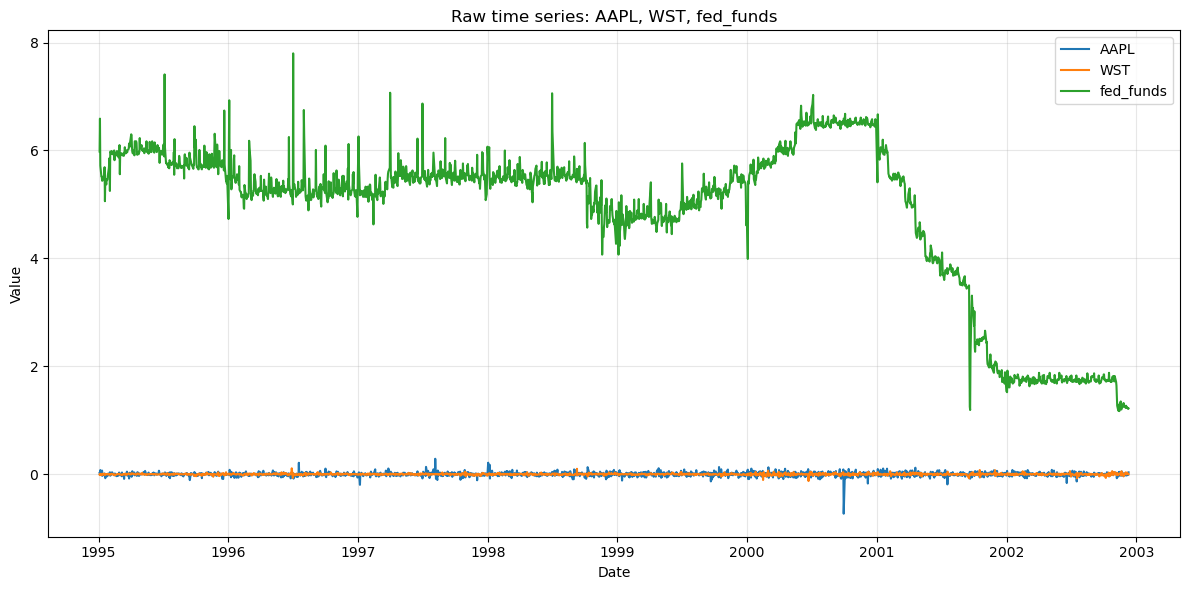

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

csv_path = "dataset_finance/eval/full_panel_preview.csv"

df = pd.read_csv(csv_path)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

cols = ["AAPL", "WST", "fed_funds"]

# --- 1) Raw series plot ---
plt.figure(figsize=(12, 6))
for col in cols:
    plt.plot(df["date"], df[col], label=col)

plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Raw time series: AAPL, WST, fed_funds")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

# # --- 2) Stock cumulative return indices + fed_funds level ---
# cum_df = df[["date"]].copy()

# for col in ["AAPL", "WST"]:
#     # Build a cumulative index starting at 100
#     cum_df[col + "_cum"] = 100 * (1 + df[col].fillna(0)).cumprod()

# cum_df["fed_funds"] = df["fed_funds"]

# fig, ax1 = plt.subplots(figsize=(12, 6))

# ax1.plot(cum_df["date"], cum_df["AAPL_cum"], label="AAPL cumulative index")
# ax1.plot(cum_df["date"], cum_df["WST_cum"], label="WST cumulative index")
# ax1.set_xlabel("Date")
# ax1.set_ylabel("Cumulative return index")
# ax1.grid(True, alpha=0.3)

# ax2 = ax1.twinx()
# ax2.plot(cum_df["date"], cum_df["fed_funds"], linestyle="--", label="fed_funds")
# ax2.set_ylabel("Fed funds rate")

# lines1, labels1 = ax1.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()
# ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

# plt.title("AAPL and WST cumulative indices with fed_funds")
# plt.tight_layout()
# plt.show()
# # plt.savefig("cum_returns_with_fedfunds.png", dpi=150)
# plt.close()

In [1]:
import os, glob, json, pathlib

CKPT_DIR = "logs/time_moe_attn_small"  # <-- change this

paths = sorted(glob.glob(os.path.join(CKPT_DIR, "*")))
print("Checkpoint dir:", CKPT_DIR)
print("Files:")
for p in paths:
    print(" -", os.path.basename(p))


Checkpoint dir: logs/time_moe_attn_small
Files:
 - config.json
 - generation_config.json
 - model.safetensors
 - training_args.bin


In [3]:
import os, glob
from safetensors.torch import safe_open


p = "logs/time_moe_attn_small/model.safetensors"
with safe_open(p, framework="pt", device="cpu") as f:
    for k in f.keys():
        shape = f.get_tensor(k).shape
        n = 1
        for d in shape:
            n *= d
        total_params += n
        tensors += 1

print(f"Found {len(safetensor_paths)} safetensors file(s)")
print(f"Found {tensors} tensors")
print(f"Total parameters: {total_params:,}")


Found 1 safetensors file(s)
Found 657 tensors
Total parameters: 160,458,240


In [4]:
import os

total_bytes = os.path.getsize(p)

print(f"Total checkpoint weight size: {total_bytes/1024**2:.2f} MB ({total_bytes/1024**3:.3f} GB)")


Total checkpoint weight size: 432.46 MB (0.422 GB)


In [5]:
import json, os

config_path = os.path.join(CKPT_DIR, "config.json")
if os.path.exists(config_path):
    config = json.load(open(config_path, "r"))
    print("config.json keys:", list(config.keys())[:30], "..." if len(config.keys()) > 30 else "")
    # Print the most interesting fields if present:
    interesting = [
        "model_type", "hidden_size", "num_hidden_layers", "num_attention_heads",
        "intermediate_size", "num_experts", "num_experts_per_tok",
        "max_position_embeddings", "input_size",
        "mamba_d_state", "mamba_d_conv", "mamba_expand", "temporal_mixer"
    ]
    for k in interesting:
        if k in config:
            print(f"{k}: {config[k]}")
else:
    print("No config.json found in", CKPT_DIR)


config.json keys: ['apply_aux_loss', 'architectures', 'attention_dropout', 'auto_map', 'dtype', 'hidden_act', 'hidden_size', 'horizon_lengths', 'initializer_range', 'input_size', 'intermediate_size', 'mamba_d_conv', 'mamba_d_state', 'mamba_expand', 'max_position_embeddings', 'model_type', 'num_attention_heads', 'num_experts', 'num_experts_per_tok', 'num_hidden_layers', 'num_key_value_heads', 'rms_norm_eps', 'rope_theta', 'router_aux_loss_factor', 'temporal_mixer', 'tie_word_embeddings', 'transformers_version', 'use_cache', 'use_dense'] 
model_type: time_moe
hidden_size: 384
num_hidden_layers: 12
num_attention_heads: 12
intermediate_size: 1536
num_experts: 8
num_experts_per_tok: 2
max_position_embeddings: 4096
input_size: 1
mamba_d_state: 16
mamba_d_conv: 4
mamba_expand: 2
temporal_mixer: attn


In [8]:
summary = {}

# params
summary["total_params"] = total_params
summary["weights_size_gb"] = total_bytes/1024**3

# config bits if available
if os.path.exists(config_path):
    for k in ["hidden_size", "num_hidden_layers", "num_attention_heads", "intermediate_size",
              "num_experts", "num_experts_per_tok", "temporal_mixer"]:
        if k in config:
            summary[k] = config[k]


summary


{'total_params': 160458240,
 'weights_size_gb': 0.4223216474056244,
 'hidden_size': 384,
 'num_hidden_layers': 12,
 'num_attention_heads': 12,
 'intermediate_size': 1536,
 'num_experts': 8,
 'num_experts_per_tok': 2,
 'temporal_mixer': 'attn'}

In [3]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from time_moe.models.configuration_time_moe import TimeMoeConfig
from time_moe.models.modeling_time_moe import TimeMoeForPrediction

# IMPORTANT: import the exact dataset your runner uses
# (adjust import path if your project structure differs)
from time_moe.datasets.time_moe_dataset import TimeMoEDataset  # <- change if needed

CKPT_DIR = "logs/time_moe_attn_small"
DATA_PATH = "dataset_finance/finetune/train_sequences.jsonl"  # <- your file
NORMALIZATION = "zero"   # or None / "max" — match training
BATCH_SIZE = 8
MAX_BATCHES = 50

device = "cuda" if torch.cuda.is_available() else "cpu"


# -----------------------
# Collate: pad sequences + attention_mask
# -----------------------
def collate_pad(batch):
    """
    batch: list of sequences returned by dataset.__getitem__
    Each seq may be np.ndarray or torch.Tensor with shape [L] or [L, input_size]
    Returns:
      input_ids: [B, Lmax, input_size]
      attention_mask: [B, Lmax] with 1 for real timesteps, 0 for padding
    """
    # convert to torch
    seqs = []
    lengths = []
    for seq in batch:
        if isinstance(seq, np.ndarray):
            seq = torch.from_numpy(seq)
        elif not torch.is_tensor(seq):
            seq = torch.tensor(seq)

        # ensure float
        if not torch.is_floating_point(seq):
            seq = seq.float()

        # ensure 2D: [L, input_size]
        if seq.dim() == 1:
            seq = seq.unsqueeze(-1)

        seqs.append(seq)
        lengths.append(seq.shape[0])

    B = len(seqs)
    Lmax = max(lengths)
    input_size = seqs[0].shape[1]

    x = torch.zeros((B, Lmax, input_size), dtype=seqs[0].dtype)
    attn = torch.zeros((B, Lmax), dtype=torch.long)

    for i, seq in enumerate(seqs):
        L = seq.shape[0]
        x[i, :L] = seq
        attn[i, :L] = 1

    return x, attn


# -----------------------
# Load model
# -----------------------
config = TimeMoeConfig.from_pretrained(CKPT_DIR)
model = TimeMoeForPrediction.from_pretrained(CKPT_DIR, config=config, torch_dtype=torch.float32)
model.to(device).eval()

num_experts = int(getattr(config, "num_experts", 0))
top_k = int(getattr(config, "num_experts_per_tok", 1))
num_layers = int(getattr(config, "num_hidden_layers", 0))

print("device:", device)
print("layers:", num_layers, "experts:", num_experts, "top_k:", top_k)
assert num_experts > 0, "This checkpoint config says num_experts=0; maybe it’s not MoE?"


# -----------------------
# Dataset + Loader
# -----------------------
dataset = TimeMoEDataset(DATA_PATH, normalization_method=NORMALIZATION)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, collate_fn=collate_pad)


@torch.no_grad()
def expert_stats_from_router_logits(router_logits_tuple, attention_mask, num_experts: int, top_k: int):
    """
    router_logits_tuple: tuple length = num_layers, each [T, E] where T = B*L
    attention_mask: [B, L] with 1/0
    Counts only positions where mask==1.
    """
    B, L = attention_mask.shape
    token_mask = attention_mask.reshape(-1).bool().cpu()  # [B*L]

    counts = torch.zeros(len(router_logits_tuple), num_experts, dtype=torch.long)
    probmass = torch.zeros(len(router_logits_tuple), num_experts, dtype=torch.float32)

    # number of real (non-pad) tokens in this batch
    real_T = int(token_mask.sum().item())

    for li, logits in enumerate(router_logits_tuple):
        # select only real tokens
        logits = logits.detach().cpu()
        logits = logits[token_mask]               # [real_T, E]

        probs = torch.softmax(logits.float(), dim=-1)
        top_probs, top_idx = torch.topk(probs, k=top_k, dim=-1)  # [real_T, K]

        flat_idx = top_idx.reshape(-1)
        flat_probs = top_probs.reshape(-1)

        counts[li].scatter_add_(0, flat_idx, torch.ones_like(flat_idx, dtype=torch.long))
        probmass[li].scatter_add_(0, flat_idx, flat_probs)

    return counts, probmass, real_T


def plot_bar(values, title, ylabel):
    values = np.asarray(values)
    plt.figure()
    plt.bar(np.arange(len(values)), values)
    plt.xlabel("Expert id")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()


# -----------------------
# Run analysis
# -----------------------
global_counts = torch.zeros(num_layers, num_experts, dtype=torch.long)
global_probmass = torch.zeros(num_layers, num_experts, dtype=torch.float32)
total_real_tokens = 0

for bi, (x, attn) in enumerate(loader):
    if bi >= MAX_BATCHES:
        break

    x = x.to(device)
    # IMPORTANT: modeling_time_moe expects attention_mask in shape [B, L] (then it makes 4D causal mask)
    # Use attn as-is.
    out = model(
        input_ids=x,
        attention_mask=attn.to(device),
        labels=None,
        return_dict=True,
        use_cache=False,
        output_attentions=False,
        output_hidden_states=False,
    )

    router_logits = out.router_logits
    if router_logits is None or len(router_logits) == 0:
        raise RuntimeError("router_logits is empty/None. This model might not be using MoE layers.")

    counts, probmass, real_T = expert_stats_from_router_logits(router_logits, attn, num_experts, top_k)
    global_counts += counts
    global_probmass += probmass
    total_real_tokens += real_T

print(f"Processed batches: {min(MAX_BATCHES, bi+1)}")
print(f"Total real tokens counted (non-padding): {total_real_tokens:,}")


# -----------------------
# Summaries
# -----------------------
counts_all = global_counts.sum(dim=0).numpy()       # [E]
probmass_all = global_probmass.sum(dim=0).numpy()   # [E]

# Each real token produces top_k assignments per layer, so:
# total assignments = total_real_tokens * top_k * num_layers
total_assignments = max(1, total_real_tokens * top_k * num_layers)

avg_assignments_per_token_per_expert = counts_all / max(1, total_real_tokens)  # "per token" across all layers/topk
share_of_assignments = counts_all / total_assignments

print("\nExpert utilization (hard top-k assignments):")
for e in range(num_experts):
    print(f"  Expert {e}: count={int(counts_all[e])}, share={share_of_assignments[e]:.4%}, avg_assign/token={avg_assignments_per_token_per_expert[e]:.6f}")

imbalance = (counts_all.max() / max(1, counts_all[counts_all > 0].min())) if (counts_all > 0).any() else float("inf")
print(f"\nImbalance ratio (max/min_nonzero) = {imbalance:.2f}")

plot_bar(counts_all, "Expert utilization (hard counts, summed over layers)", "Top-k assignments")
plot_bar(probmass_all, "Expert utilization (soft prob mass, summed over layers)", "Top-k probability mass")

device: cpu
layers: 12 experts: 8 top_k: 2


RuntimeError: expected m1 and m2 to have the same dtype, but got: double != float